Date: 25th July 2026

Author: Bipul Pandey

Objectives:  

    - We will load the learned LRBM models
    - We will generate samples from them
    - We will show the preservation of statistics
    - We will also show the matching of energy landscapes


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import r2_score
from scipy.stats import pearsonr

import sys
sys.path.append("../Scripts/")
from LRBM_Compressed_Potts import *
from Frequency_Calculators import *


print("="*30 ,"Options:", "="*30)
print("     1 : Toy model of evolution")
print("     2: Images- MNIST")
print("     3: Sentences - Animal Simple Wikipedia")
print("     4: Sentences - Alice in Wonderland")
print("     5: Protein - Chorismate Mutase")
print("="*70)

============================== Options: ==============================
     1 : Toy model of evolution
     2: Images- MNIST
     3: Sentences - Animal Simple Wikipedia
     4: Sentences - Alice in Wonderland
     5: Protein - Chorismate Mutase


In [5]:
def Energy_Given_Model(Ohe_Array, Model):
    num_part = Model.num_of_partitions
    Energy_by_scale ={}
    Total_Energy = np.zeros(len(Ohe_Array))
    for p in range(0, num_part):
        Data_self, Data_interact = Model.Data_Partition(Ohe_Array, p)
        Weight_part = Model.Weights[p]
        Bias_part = Model.Bias[p]
        Energy_p = Model.Energy_Array_given_partition_easy(Ohe_Array, p)
        name_p = f"Scale_{p+1}_Energy"
        Energy_by_scale[name_p] = Energy_p
        Total_Energy+=Energy_p
    Energy_by_scale["Total_Energy"] = Total_Energy

    return Energy_by_scale

In [6]:
Experiment = 1


Experiment = int(Experiment)

if Experiment ==1:
    print("Population Toy Model")
    Data_loc = "../../Training_Data/Toy_Model_Evolution/Training_Data_Final_5000_Ground_Truth_Population.csv"
    Gen_loc = "../../Results/Generated_Data/Toy_Model_Evolution/LRBM_Generated_Population.csv"
    Model_loc = "../../Model_Parameters/Toy_Model_Evolution_LRBM_Toy/"
    Compress_Alphabets = False

elif Experiment ==2:
    print("MNIST")
    Data_loc =  "../../Training_Data/Images_MNIST/Training_Data_MNIST_Binarized_500_images.csv"
    Gen_loc = "../../Results/Generated_Data/Images_MNIST/LRBM_Generated_MNIST_Images.csv"
    Model_loc ="../../Model_Parameters/Images_LRBM_MNIST/"
    Compress_Alphabets = False

elif Experiment == 3:
    print("Sentences- Animal:Simple Wikipedia")
    Data_loc = "../../Training_Data/Sentences_Wiki/Training_Data_Wiki_1589_Tokenized_Sentences.csv"
    Gen_loc = "../../Results/Generated_Data/Sentences_Wiki/LRBM_Generated_Wiki_Sentences.csv"
    Model_loc =  "../../Model_Parameters/Sentences_LRBM_Wiki/"
    Compress_Alphabets = True

elif Experiment ==4:
    print("Sentences - Alice in Wonderland")
    Data_loc ="../../Training_Data/Sentences_Alice/Training_Data_Alice_716_Tokenized_Sentences.csv"
    Gen_loc = "../../Results/Generated_Data/Sentences_Alice/LRBM_Generated_Alice_Sentences.csv"
    Model_loc =  "../../Model_Parameters/Sentences_LRBM_Alice/"
    Compress_Alphabets = True

else:
    Experiment == 5
    print("Protein : Chorismate Mutase")
    Data_loc = "../../Training_Data/Protien_Chorismate_Mutase/Training_Data_Natural_1130_Chorismate_Mutase.csv"
    Gen_loc = "../../Results/Generated_Data/Protein_Chorismate_Mutase/LRBM_Generated_Chorismate_Mutase.csv"
    Model_loc =  "../../Model_Parameters/Proteins_LRBM_CM/"
    Compress_Alphabets = False


Population Toy Model


In [7]:
## Loading Training Data: ---
Training_Dataset = pd.read_csv(Data_loc)

Columns = Training_Dataset.columns
Postion_Columns=[]
for c in Columns:
    if c[0:3] == "Pos":
        Postion_Columns.append(c)
print("Number of Positions=", len(Postion_Columns))
Compact_Training_Dataset = np.array(Training_Dataset[Postion_Columns])
##------------

## ----Loading Scales ----
Entropic_Partition_Map = np.loadtxt(Model_loc+"Entropic_Scales_Partition_Map.txt")

Number of Positions= 16


In [8]:
LRBM = Compressed_LRBM(Compact_Training_Dataset, Entropic_Partition_Map, compressed=Compress_Alphabets, extra_character="*zz")

Number of Partitions Set= 4
..Setting Partition Map..
Number of partitions = 4
semi-warm start. Matching only the frequencies
semi-warm start. Matching only the frequencies


In [9]:
## We also want to import the trained model weights and biases:

Load_Model_Parameters= True

if Load_Model_Parameters:
    print("Loading Trained Model Parameters.")
    num_scales = np.shape(Entropic_Partition_Map)[0]
    for s in range(0, num_scales):
        Weight_s = np.loadtxt(Model_loc+ f"Scale_{s+1}_Weight.txt")
        Bias_s = np.loadtxt(Model_loc+ f"Scale_{s+1}_Bias.txt")
        LRBM.Weights[s] = Weight_s
        LRBM.Bias[s] = Bias_s
        print(f"Scale_{s+1} Parameters Loaded.")
        
else:
    print("Model Parameters are Random Initial Values")

Loading Trained Model Parameters.
Scale_1 Parameters Loaded.
Scale_2 Parameters Loaded.
Scale_3 Parameters Loaded.
Scale_4 Parameters Loaded.


## Sample Generation:

In [10]:
num_samples_to_generate = 2000
MCMC_iteration = 300

Final_states=[]
Random_Seed = []


for i in tqdm(range(0, num_samples_to_generate)):

    fin_st_i, seed_i = LRBM.Gibbs_Sampling_through_Layers(MCMC_iteration)
    Final_states.append(fin_st_i)
    Random_Seed.append(seed_i)


Fresh_Generated_Data = np.array(Final_states)
Random_Starting_Seeds = np.array(Random_Seed)

100%|██████████| 2000/2000 [01:15<00:00, 26.35it/s]


## Visualizing One hot encoded Training Data and Freshly Generated Data:

In [11]:
## One hot encoded Training data
Ohe_training_data = LRBM.unfurled_data

## One hot encoded Generated Data
Ohe_generated_data = Fresh_Generated_Data

##3 One hot encoded Random Seed
Ohe_random_seed = Random_Starting_Seeds


Text(0.5, 1.0, 'One hot encoded Random Seed')

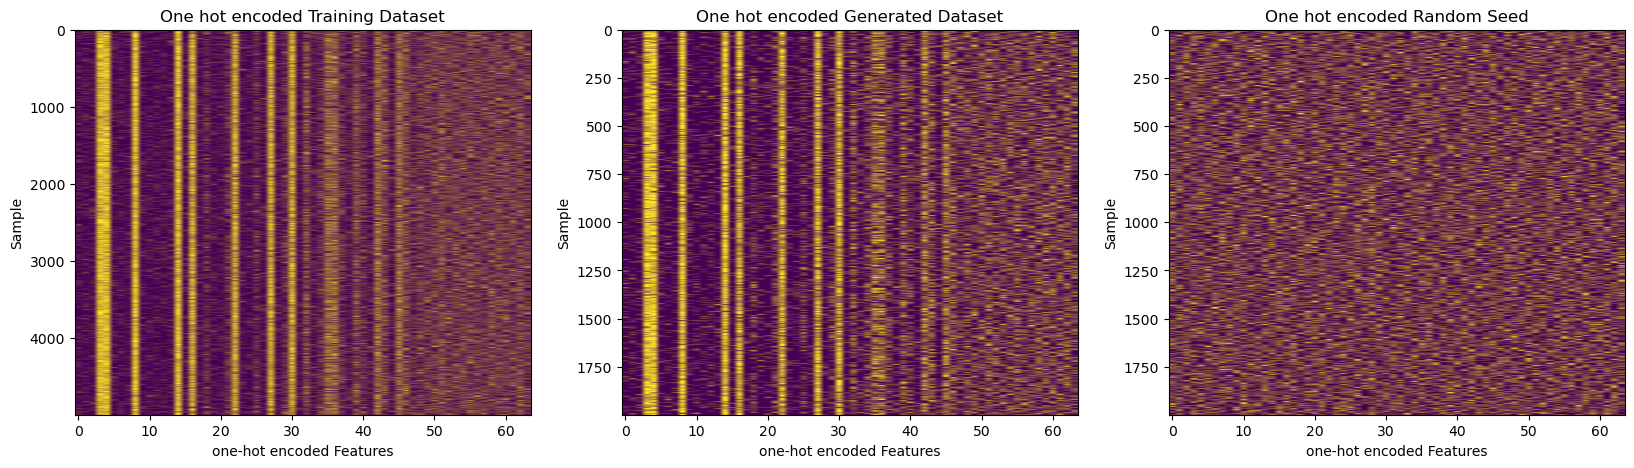

In [12]:
fig, ax = plt.subplots(1,3,figsize=(20,5))
ax[0].imshow(Ohe_training_data, aspect = "auto")
ax[1].imshow(Ohe_generated_data,aspect = "auto")
ax[2].imshow(Ohe_random_seed,aspect = "auto")

for i in range(0,3):
    ax[i].set_xlabel("one-hot encoded Features")
    ax[i].set_ylabel("Sample")

ax[0].set_title("One hot encoded Training Dataset")
ax[1].set_title("One hot encoded Generated Dataset")
ax[2].set_title("One hot encoded Random Seed")

_____
## Energy Calculations for Training and Generated Dataset:

In [13]:
Energy_evol_Training_Data = Energy_Given_Model(Ohe_training_data, LRBM)
Energy_evol_Generated_Data = Energy_Given_Model(Ohe_generated_data, LRBM)
Energy_evol_Random_Seed = Energy_Given_Model(Ohe_random_seed, LRBM)

-----------------
## Energy Evolution Plots:

### 1. Scale wise Energy:
Now we will plot the energy contribution by each scale for both training and generated data

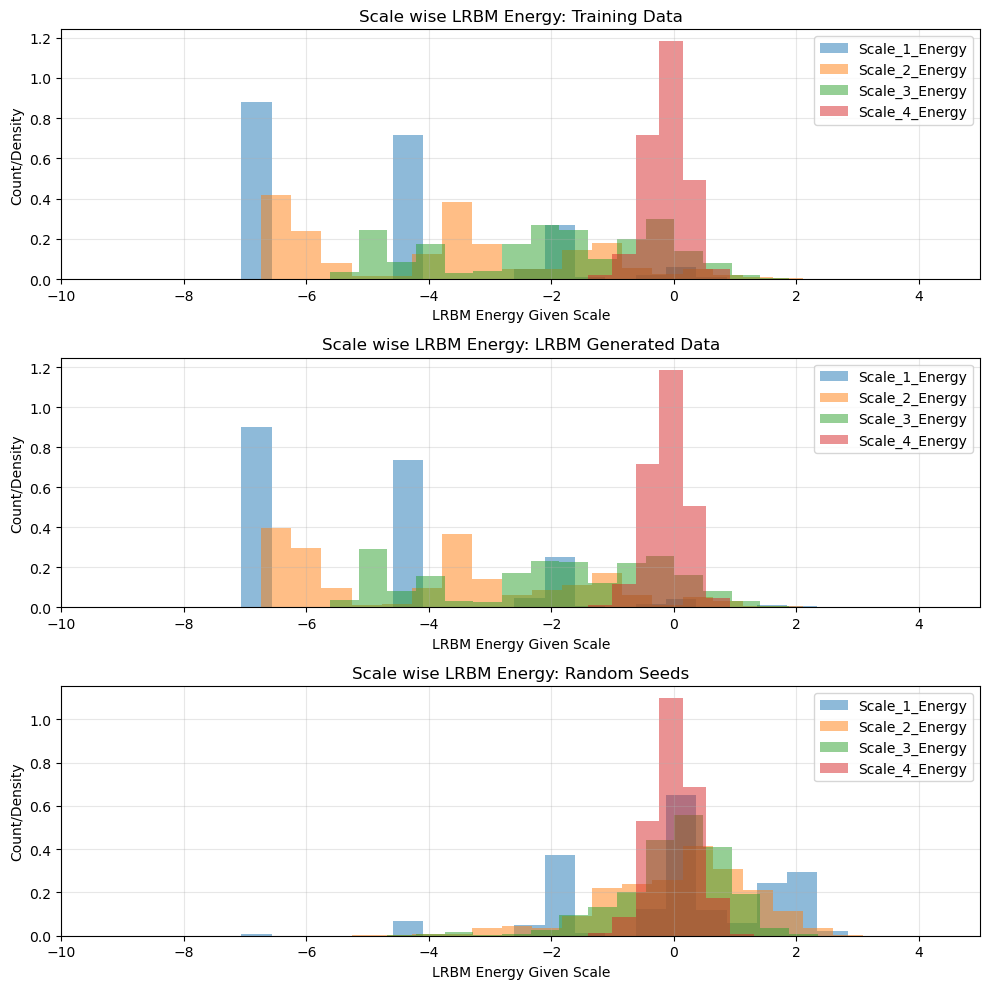

In [14]:
num_bins = 60
density = True

###--------------------
fig,ax = plt.subplots(3,1,figsize=(10,10))

for i in range(0, LRBM.num_of_partitions):
    scale_name = f"Scale_{i+1}_Energy"
    cts_train, bins_train = np.histogram(Energy_evol_Training_Data[scale_name], num_bins)
    cts_gen, bins_gen = np.histogram(Energy_evol_Generated_Data[scale_name], num_bins)
    max_val = np.max([bins_train[-1], bins_gen[-1]])+10
    min_val = np.min([bins_train[0], bins_gen[0]])-10

    Bin_used = np.linspace(min_val, max_val, num_bins)

    ax[0].hist(Energy_evol_Training_Data[scale_name], bins = Bin_used, density=density, alpha = 0.5, label = scale_name)
    ax[1].hist(Energy_evol_Generated_Data[scale_name], bins = Bin_used, density=density, alpha = 0.5,label = scale_name)
    ax[2].hist(Energy_evol_Random_Seed[scale_name], bins = Bin_used, density=density, alpha = 0.5,label = scale_name)
    

for i in range(0,3):
    ax[i].grid(alpha = 0.3)
    ax[i].legend()
    ax[i].set_xlabel("LRBM Energy Given Scale")
    ax[i].set_ylabel("Count/Density")
    ax[i].set_xlim(-10,5)
  

ax[0].set_title("Scale wise LRBM Energy: Training Data")
ax[1].set_title("Scale wise LRBM Energy: LRBM Generated Data")
ax[2].set_title("Scale wise LRBM Energy: Random Seeds")

plt.tight_layout()
plt.show()

_____
### Frequency preservation:


Now we will show the preservation of statistics test of:

        - Individual frequencies
        - Pairwise correlations
        - triplet correlations (to reasonable degree)

Lets keep in mind that the model has no third order terms to exactly model triplet interactions




In [15]:
Compact_LRBM_Generated_Dataset=[]
for elem in Fresh_Generated_Data:
    elem_comp = LRBM.One_hot_decoder(elem)
    Compact_LRBM_Generated_Dataset.append(elem_comp)
Compact_LRBM_Generated_Dataset = np.array(Compact_LRBM_Generated_Dataset)

Dataset_1 = Compact_Training_Dataset
Dataset_2 = Compact_LRBM_Generated_Dataset

# Find the unique alphabets in Training Data
Alphabets = Alphabet_list(Dataset_1)
Num_alphabets = len(Alphabets)

print("Number of unique alphabets=", Num_alphabets)

### One hot encoding Training and generated data

Ohe_dataset_1 = One_hot_encoder_Array(Dataset_1, Alphabets)
Ohe_dataset_2= One_hot_encoder_Array(Dataset_2, Alphabets)

### Integer representation

Int_repr_dataset_1 = Integer_encode_Array(Dataset_1, Alphabets)
Int_repr_dataset_2 = Integer_encode_Array(Dataset_2, Alphabets)

Number of unique alphabets= 4


In [16]:
### ------ For natural or Ground Truth (GT) Data ------

## since triplet calculations are slow, I set it to false here
## set it to true if you want to do them
Perform_triplet_calculation = True

print("__" * 20)
print(f"Triplet Calculation is set to -> {Perform_triplet_calculation}")
print("__" * 20)
### ----------------------------------------------------

Sing_Freq_GT= Singlet_Frequency(Ohe_dataset_1, Num_alphabets)
PW_Freq_GT,_ = Pairwise_Frequency(Ohe_dataset_1, Num_alphabets)
PW_Corr_GT,_ = Pairwise_Correlation(Ohe_dataset_1, Num_alphabets)

if Perform_triplet_calculation:
    Trip_Corr_GT =Triplet_Correlation(Int_repr_dataset_1, Ohe_dataset_1, Num_alphabets)
print("Calculations for Naturals =>Done")

### ------ For LRBM Data ------
Sing_Freq_LRBM= Singlet_Frequency(Ohe_dataset_2, Num_alphabets)
PW_Freq_LRBM,_ = Pairwise_Frequency(Ohe_dataset_2, Num_alphabets)
PW_Corr_LRBM,_ = Pairwise_Correlation(Ohe_dataset_2, Num_alphabets)
if Perform_triplet_calculation:
    Trip_Corr_LRBM =Triplet_Correlation(Int_repr_dataset_2, Ohe_dataset_2, Num_alphabets)
print("Calculations for LRBM =>Done")

________________________________________
Triplet Calculation is set to -> True
________________________________________
Calculations for Naturals =>Done
Calculations for LRBM =>Done


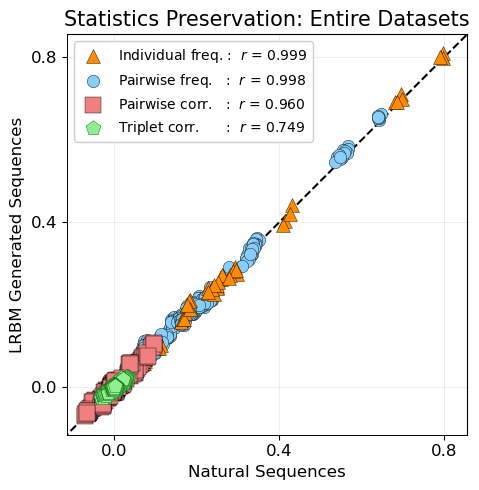

In [17]:

# --------- -Data -------------

individual_nat  = np.array(Sing_Freq_GT)
individual_syn  = np.array(Sing_Freq_LRBM)

pairwise_freq_nat  = np.array(PW_Freq_GT)
pairwise_freq_syn  = np.array(PW_Freq_LRBM)

pairwise_corr_nat  = np.array(PW_Corr_GT)
pairwise_corr_syn  = np.array(PW_Corr_LRBM)


if Perform_triplet_calculation:
    triplet_nat  = np.array(Trip_Corr_GT)
    triplet_syn  = np.array(Trip_Corr_LRBM)

# ── Plot config ───────────────────────────────────────────────────────

if Perform_triplet_calculation:
    datasets = [
        dict(nat=individual_nat,   syn=individual_syn,
            label='Individual freq. ',  color='darkorange', marker='^', size=100, edgecolor = "black", zorder = 3),
        dict(nat=pairwise_freq_nat, syn=pairwise_freq_syn,
            label='Pairwise freq.   ',    color='lightskyblue', marker='o', size=80, edgecolor = "black", zorder = 2),
        dict(nat=pairwise_corr_nat, syn=pairwise_corr_syn,
            label='Pairwise corr.   ',    color='lightcoral', marker='s', size=125, edgecolor = "black", zorder = 3),
        dict(nat=triplet_nat,       syn=triplet_syn,
            label='Triplet corr.      ',     color='lightgreen', marker='p', size=125, edgecolor = "darkgreen", zorder =3),
    ]

else:
    datasets = [
        dict(nat=individual_nat,   syn=individual_syn,
            label='Individual freq. ',  color='darkorange', marker='^', size=30, edgecolor = "black", zorder = 3),
        dict(nat=pairwise_freq_nat, syn=pairwise_freq_syn,
            label='Pairwise freq.   ',    color='lightskyblue', marker='o', size=30, edgecolor = "black", zorder = 2),
        dict(nat=pairwise_corr_nat, syn=pairwise_corr_syn,
            label='Pairwise corr.   ',    color='lightcoral', marker='s', size=65, edgecolor = "black", zorder = 3)
    ]


for d in datasets:
    r2   = r2_score(d['nat'], d['syn'])
    rmse = np.sqrt(np.mean((d['nat'] - d['syn']) ** 2))
    pson_r= pearsonr(d['nat'], d['syn'])[0]
    d['r2']= r2
    d['rmse']= rmse
    d['pearson_r'] = pson_r

# ── Figure ────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 5))

# Determine global axis limits across all datasets
all_nat = np.concatenate([d['nat'] for d in datasets])
all_syn = np.concatenate([d['syn'] for d in datasets])
lo = min(all_nat.min(), all_syn.min())
hi = max(all_nat.max(), all_syn.max())
pad = (hi - lo) * 0.05
lo, hi = lo - pad, hi + pad



# Scatter each statistic + annotation
annotation_y = 0.97  # tracks vertical position of text annotations
for d in datasets:
    
    pson = d['pearson_r']
    label_o = f"{d['label']}:  $r$ = {pson :.3f}"
    ax.scatter(d['nat'], d['syn'],
               color=d['color'], marker=d['marker'],
               s=d['size'], alpha=1, linewidths=0.3,
               edgecolors=d['edgecolor'], zorder=d['zorder'], label=label_o)

    annotation_y -= 0.07

# ── Axes formatting ───────────────────────────────────────────────────
ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)
ax.set_aspect('equal')
ax.set_xlabel('Natural Sequences', fontsize=12)
ax.set_ylabel('LRBM Generated Sequences', fontsize=12)
ax.set_title('Statistics Preservation: Entire Datasets', fontsize=15)


ax.tick_params(labelsize=10)
ax.grid(linewidth=0.4, alpha=0.4, zorder=0)

ax.set_axisbelow(True)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(True)
for spine in ['left', 'bottom']:
    ax.spines[spine].set_linewidth(0.7)

# Legend (shapes/colors only, no duplicating the text annotations)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, fontsize=10, frameon=True,
          framealpha=1, edgecolor='#cccccc',
          loc='upper left')
#plt.xlim(-0.2,1)
#plt.ylim(-0.2,1)
# 1:1 diagonal
ax.plot([-0.2, 1], [-0.2, 1], color='black', linewidth=1.5,
        linestyle='--', zorder=1)


ax.set_xticks([0,0.4,0.8])
ax.set_yticks([0,0.4,0.8])
ax.tick_params(labelsize = 12)

plt.tight_layout()


save = False
Fig_path = "../../Plots/"
if save == True:

    plt.savefig(Fig_path+'statistics_preservation_LRBM.pdf', transparent= True, dpi=300, bbox_inches='tight')
    plt.savefig(Fig_path+'statistics_preservation_LRBM.png', dpi=300, bbox_inches='tight')
plt.show()

### End of Notebook.